<a href="https://colab.research.google.com/github/KRBAI/Assignment-2/blob/main/Question5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

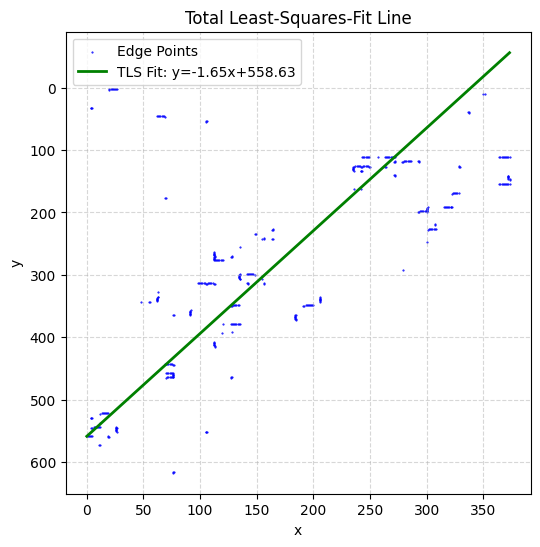

TLS Slope (m): -1.6471648837385575


In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load the cropped segment of the image
img = cv.imread('/content/drive/MyDrive/Assignment2/Images/Screen Shot 2026-03-18 at 16.18.34.png', cv.IMREAD_GRAYSCALE)

x_mean = np.mean(x)
y_mean = np.mean(y)
x_centered = x - x_mean
y_centered = y - y_mean

data = np.vstack([x_centered, y_centered]).T
u, s, vh = np.linalg.svd(data)

a, b = vh[1, :]

m_tls = -a / b
c_tls = y_mean - m_tls * x_mean

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=1, c='blue', marker='.', label='Edge Points')

x_plot = np.array([np.min(x), np.max(x)])
y_plot = m_tls * x_plot + c_tls

plt.plot(x_plot, y_plot, color='green', linewidth=2, label=f'TLS Fit: y={m_tls:.2f}x+{c_tls:.2f}')

plt.gca().invert_yaxis()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Total Least-Squares-Fit Line')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"TLS Slope (m): {m_tls}")